<font color="black" size="10"><b>Step 1.Visualization of drug sensitivity predicted by DeepTNR</b></font>

CRC1 barcode example: ['AAACAAGTATCTCCCA-1' 'AAACACCAATAACTGC-1' 'AAACATTTCCCGGATT-1']
Region data barcode example: ['AAACAAGTATCTCCCA-1' 'AAACACCAATAACTGC-1' 'AAACATTTCCCGGATT-1']


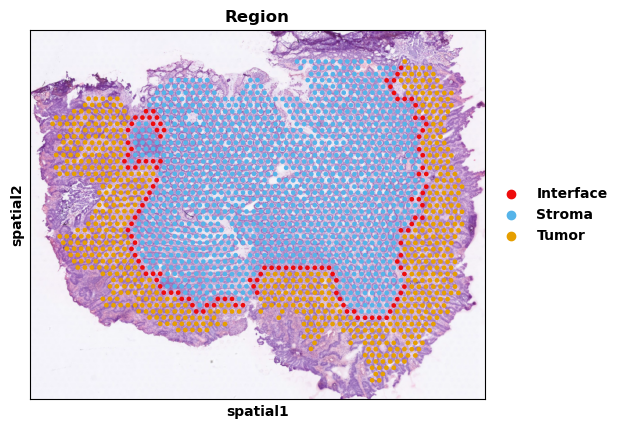

['in_tissue', 'array_row', 'array_col', 'IRINOTECAN_Drug_Sensitivity_Predictions', 'Region_interface']


In [2]:
import sys
import pickle
import os
import warnings
import random
from typing import Optional, List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import scanpy as sc
import anndata
import torch
import scvi
import cell2location  
import Spatial_proximity_effect

from libpysal.weights import KNN
from esda import Moran
from statsmodels.stats.multitest import multipletests
from scipy.ndimage import gaussian_filter1d, distance_transform_edt
from scipy.spatial import KDTree
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

# Set matplotlib parameters
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'

# Fix one_hot issue
class OneHotFixer:
    @staticmethod
    def one_hot(index, n_cat):
        return torch.nn.functional.one_hot(index.long(), n_cat)

scvi.nn._utils.one_hot = OneHotFixer.one_hot
sys.modules['scvi.nn._utils'].one_hot = OneHotFixer.one_hot

# Color mapping
Region_color = {
    'Stroma': '#56b4e9',  
    'Tumor': '#E69f00',   
    'Interface': '#EE0C0C'        
}

# Load data
CRC1 = sc.read("CRC1.h5ad")      ###Replace with your data!!
drug_name = 'Irinotecan'     ### Replace with your data!!

# Load and add region information
region_data = pd.read_csv("CRC1_region_interface.csv", index_col=0)     ###Use the pathologist-corrected region annotation file
print("CRC1 barcode example:", CRC1.obs.index[:3].values)
print("Region data barcode example:", region_data.index[:3].values)
CRC1.obs["Region_interface"] = region_data["Region_interface"]

adata = CRC1

# Plot spatial region distribution
sc.pl.spatial(
    adata, 
    color='Region_interface',
    palette=Region_color,
    na_in_legend=False, 
    title='Region'
)

# Display obs information
print(adata.obs.columns.tolist())

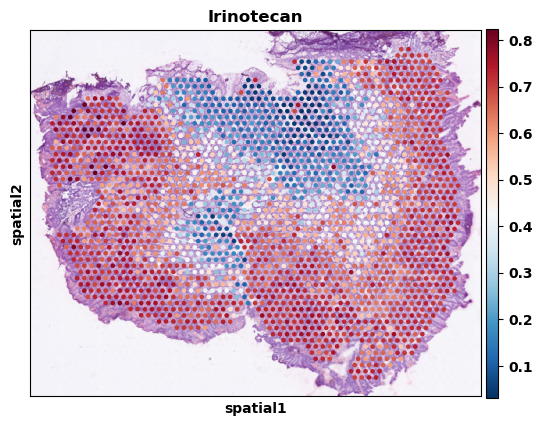

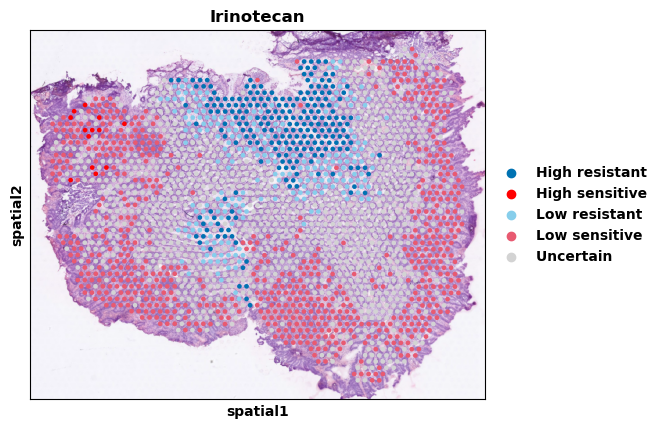

In [3]:
def classify_sensitivity(value):
    if 0.80<=value<=1.0:
        return 'High sensitive'
    elif 0.70<=value<0.80:
        return 'Low sensitive'
    elif 0.30<value<=0.70:
        return 'Uncertain '
    elif 0.15<value<=0.30:
        return 'Low resistant'
    elif 0.0<=value<=0.15:
        return 'High resistant'
    else:
        return 'Unknown'

def add_sensitivity_classification(adata,sensitivity_col):
    adata.obs['Sensitivity']=adata.obs[sensitivity_col].astype(float).apply(classify_sensitivity)
    return adata

def plot_spatial_distribution(adata,color,palette,save_name,title_name):
    sc.pl.spatial(
        adata,
        color=color,
        palette=palette if color=='Sensitivity' else None,
        cmap='RdBu_r' if color!='Sensitivity' else None,
        na_in_legend=False,
        save=save_name,
        title=title_name
    )

adata=sc.read_h5ad('CRC1.h5ad')

sensitivity_col='IRINOTECAN_Drug_Sensitivity_Predictions'   ###Replace with your drug name!!

adata=add_sensitivity_classification(adata,sensitivity_col)

Drug_Sensitivity_map={
    '1.0':'#E69f00',
    '0.0':'#56b4e9'
}

plot_spatial_distribution(
    adata,
    sensitivity_col,
    Drug_Sensitivity_map,
    'CRC1_Irinotecan_score.pdf',
    'Irinotecan'
)

Cell_color={
    'High sensitive':'#FF0000',
    'Low sensitive':'#e85a71',
    'Uncertain ':'#D3D3D3',
    'High resistant':'#0072B2',
    'Low resistant':'#87CEEB',
    'Unknown':'#808080'
}

plot_spatial_distribution(
    adata,
    'Sensitivity',
    Cell_color,
    'CRC1_Irinotecan.pdf',
    'Irinotecan'
)

adata.obs[['IRINOTECAN_Drug_Sensitivity_Predictions']].to_csv(
    'CRC1_Irinotecan.csv',
    index=True

)


<font color="black" size="10"><b>Step 2.Now performing Spatial autocorrelation analysis!!</b></font>

STEP 1: Loading AnnData object
✓ Successfully loaded AnnData with 2203 cells
✓ Spatial coordinates available: True

STEP 2: Calculating spatial autocorrelation (Moran's I)

Processing drug: IRINOTECAN
  - Sensitive: Moran's I = 0.2134, p-value = 0.0010 **, n = 715
  - Resistant: Moran's I = 0.4842, p-value = 0.0010 **, n = 453
  - Unknown: No data

STEP 2.5: FDR Multiple Testing Correction

 FDR Correction Summary:
  - Number of tests: 2
  - Significant (raw p < 0.05): 2
  - Significant (FDR p < 0.05): 2

✓ Results saved to CRC1_Result\CRC1_SpatialAutocorrelation\CRC1_spatial_autocorrelation_results.csv

STEP 3: Plotting results for each drug


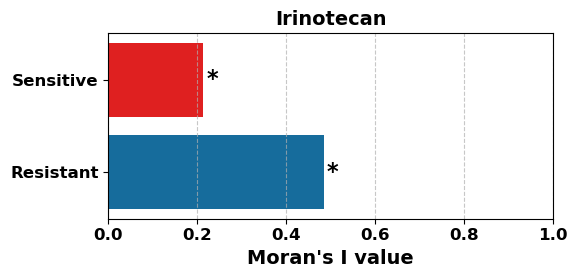

  - IRINOTECAN: Plot saved to CRC1_Result\CRC1_SpatialAutocorrelation\plots\IRINOTECAN_spatial_autocorrelation.png

RESULTS SUMMARY

 Summary Statistics:
  - Total drugs analyzed: 1
  - Total calculations: 2

 Significant results (FDR-adjusted p < 0.05):
  - Irinotecan: 2 significant categories

  By category:
    - Irinotecan: Sensitive - Moran's I = 0.2134
    - Irinotecan: Resistant - Moran's I = 0.4842

 Top 3 positive Moran's I:
  - Irinotecan - Resistant: 0.4842 (FDR significant)
  - Irinotecan - Sensitive: 0.2134 (FDR significant)

 Top 3 negative Moran's I:
  - Irinotecan - Sensitive: 0.2134 (FDR significant)
  - Irinotecan - Resistant: 0.4842 (FDR significant)

 Results saved in: CRC1_Result\CRC1_SpatialAutocorrelation
   - CSV file: CRC1_Result\CRC1_SpatialAutocorrelation\CRC1_spatial_autocorrelation_results.csv
   - Plots folder: CRC1_Result\CRC1_SpatialAutocorrelation\plots


In [4]:
import Spatial_autocorrelation

adata_path = "CRC1.h5ad"
cancer_sample_name = "CRC1"
drugs = ["IRINOTECAN"]
titles = ["Irinotecan"]

results = Spatial_autocorrelation.analyze_and_plot_spatial_autocorrelation(
    adata_path=adata_path,
    drugs=drugs,
    cancer_sample_name=cancer_sample_name,
    titles=titles,
    k=6,
    save_folder=f"{cancer_sample_name}_Result"
)

<font color="black" size="10"><b>Step 3.Now performing Spatial proximity analysis!!</b></font>

AAACAAGTATCTCCCA-1    0.566648
AAACACCAATAACTGC-1    0.690592
AAACATTTCCCGGATT-1    0.653782
AAACCCGAACGAAATC-1    0.715927
AAACCGGGTAGGTACC-1    0.751186
Name: CRC1_Irinotecan, dtype: float64
Starting spatial proximity effect analysis for CRC1
Random seed: 42

Step 0: Extracting obs data from AnnData...
  Data shape: (2203, 158)

Step 1-3: Calculating interface distance...
  Distance range: -1.0000 to 1.0000
  Positive distances (tumor): 869
  Negative distances (stroma): 1208

Step 4: Extracting cell types...
  Found 40 cell types
  First few: ['Anti-inflammatory', 'BEST4+ Enterocytes', 'CD19+CD20+ B', 'CD4+ T cells', 'CD8+ T cells']

Step 5-6: Calculating spatial density...

Step 7: Calculating drug gradient...
  Using drug column: CRC1_Irinotecan
  Drug values range: 0.0308 to 0.8247

Step 8-9: Calculating proximity scores and permutation test...
  Parameters: radius=0.2, min_neighbors=50, n_perm=100
  Random seed: 42
  Calculating real proximity scores...
    Total spots: 2203
   

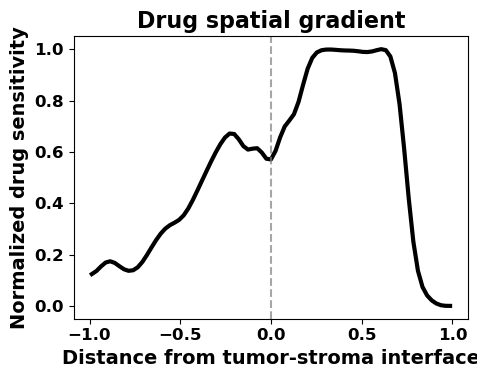

Figure saved: figure_outputs\CRC1_Irinotecan_spatial_density.pdf


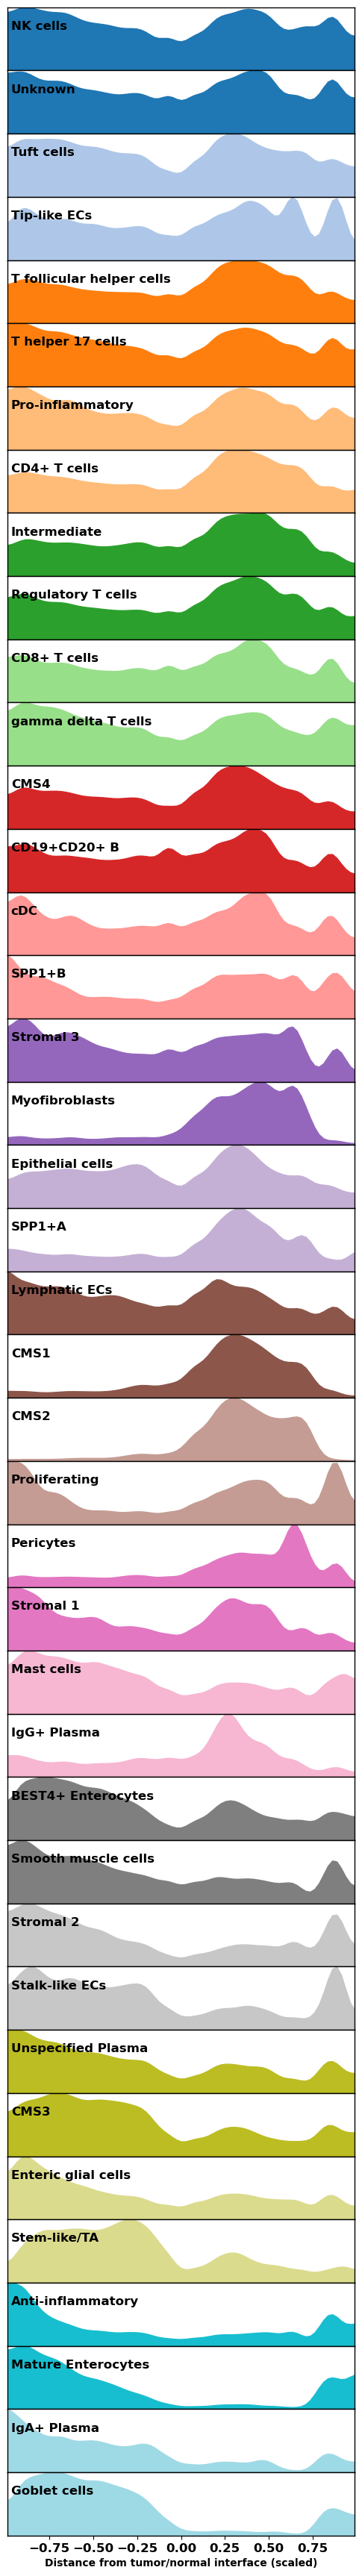

Figure saved: figure_outputs\CRC1_Irinotecan_proximity_effect.pdf


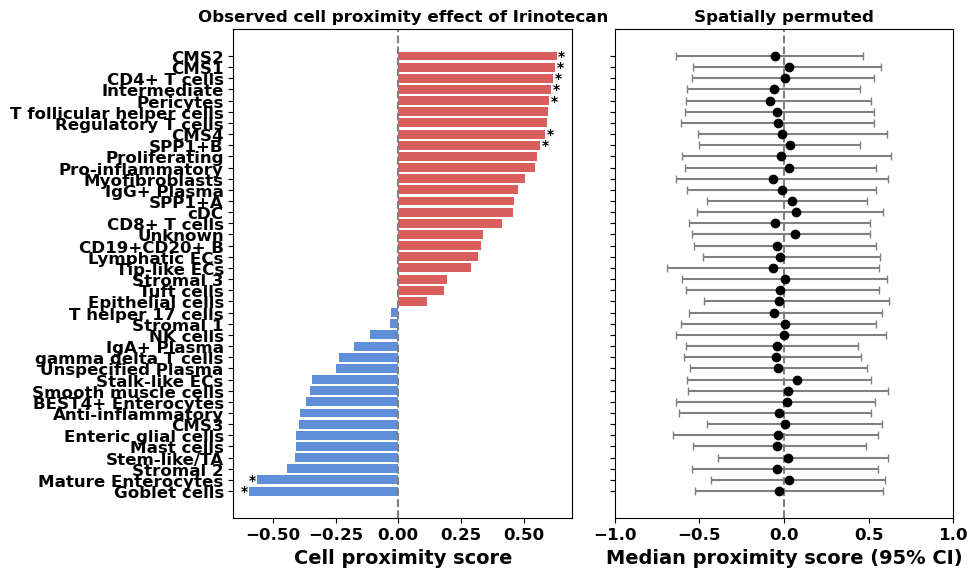


Analysis completed successfully!
                           proximity_score   p_value
cell_type                                           
Goblet cells                     -0.594877  0.049505
Mature Enterocytes               -0.562447  0.049505
Stromal 2                        -0.442354  0.148515
Stem-like/TA                     -0.411518  0.118812
Mast cells                       -0.407058  0.227723
Enteric glial cells              -0.405686  0.247525
CMS3                             -0.393693  0.217822
Anti-inflammatory                -0.391015  0.188119
BEST4+ Enterocytes               -0.366527  0.316832
Smooth muscle cells              -0.350185  0.306931
Stalk-like ECs                   -0.345045  0.366337
Unspecified Plasma               -0.249450  0.405941
gamma delta T cells              -0.238209  0.425743
IgA+ Plasma                      -0.177161  0.514851
NK cells                         -0.112264  0.742574
Stromal 1                        -0.034007  0.871287
T helper 17 

In [5]:
import pandas as pd
import scanpy as sc
import Spatial_proximity_effect
adata = sc.read_h5ad('CRC1_updated.h5ad')  ###AnnData object with cell deconvolution results!!!!
                                           ###You should also perform such operations on your AnnData object!!



def add_drug_sensitivity(adata, csv_path, drug_name):
    data = pd.read_csv(csv_path, index_col=0)
    col = data.columns[0] if data.shape[1] == 1 else [c for c in data.columns if drug_name in c][0]
    adata.obs[f"CRC1_{drug_name}"] = adata.obs.index.map(data[col].to_dict())
    return adata

adata = add_drug_sensitivity(adata, "CRC1_Irinotecan.csv", "Irinotecan")
print(adata.obs.CRC1_Irinotecan.head())

results = Spatial_proximity_effect.analyze_spatial_proximity_effect(
    adata=adata,
    drug_name="Irinotecan",
    sample_id="CRC1",
    n_perm=100,           # number of permutations
    radius=0.2,           # neighborhood radius
    min_neighbors=50,     # minimum number of neighbors
    save_figures=True,
    output_dir="figure_outputs",
    verbose=True,
    random_seed=42
)

# View results
print(results['proximity_scores'])